<a href="https://colab.research.google.com/github/RAseng77/AIFFEL_QUEST_RS/blob/master/Exploration/Ex05/EXPLORATION_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.3.2
1.7.0
0.13.2


In [ ]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

In [ ]:
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

# 파일 읽기 및 명사 추출하기
def read_token(file_name):
    okt = Okt()
    result = []
    print(f"{file_name} 파일을 읽고있습니다.")

    with open(os.getenv('HOME') + '/work/weat/data/' + file_name, 'r') as fread:
        while True:
            line = fread.readline()
            if not line: break

            # 형태소 분석 (Stemming, Normalization 적용)
            tokenlist = okt.pos(line, stem=True, norm=True)

            # 명사만 골라서 담기
            for word in tokenlist:
                if word[1] in ["Noun"]:
                    result.append(word[0])
        return ' '.join(result)



In [ ]:
art = read_token(art_txt)
gen = read_token(gen_txt)

synopsis_art.txt 파일을 읽고있습니다.
synopsis_gen.txt 파일을 읽고있습니다.


In [ ]:
genre_data = []
for file_name in genre_txt:
    genre_data.append(read_token(file_name))

synopsis_SF.txt 파일을 읽고있습니다.
synopsis_family.txt 파일을 읽고있습니다.
synopsis_show.txt 파일을 읽고있습니다.
synopsis_horror.txt 파일을 읽고있습니다.
synopsis_etc.txt 파일을 읽고있습니다.
synopsis_documentary.txt 파일을 읽고있습니다.
synopsis_drama.txt 파일을 읽고있습니다.
synopsis_romance.txt 파일을 읽고있습니다.
synopsis_musical.txt 파일을 읽고있습니다.
synopsis_mystery.txt 파일을 읽고있습니다.
synopsis_crime.txt 파일을 읽고있습니다.
synopsis_historical.txt 파일을 읽고있습니다.
synopsis_western.txt 파일을 읽고있습니다.
synopsis_adult.txt 파일을 읽고있습니다.
synopsis_thriller.txt 파일을 읽고있습니다.
synopsis_animation.txt 파일을 읽고있습니다.
synopsis_action.txt 파일을 읽고있습니다.
synopsis_adventure.txt 파일을 읽고있습니다.
synopsis_war.txt 파일을 읽고있습니다.
synopsis_comedy.txt 파일을 읽고있습니다.
synopsis_fantasy.txt 파일을 읽고있습니다.


In [ ]:
from gensim.models import Word2Vec

all_data = [art, gen] + genre_data
tokenized_data = [text.split() for text in all_data]

model = Word2Vec(sentences=tokenized_data, vector_size=100, window=5, min_count=3, sg=0)

In [ ]:
vectorizer = TfidfVectorizer()
X_total = vectorizer.fit_transform(all_data)

In [ ]:
print(X_total.shape)

(23, 42802)


In [ ]:
# TF-IDF
vectorizer = TfidfVectorizer()
X_total = vectorizer.fit_transform(all_data)

# 중복없는 대표 단어 추출
def get_distinct_words(target_idx, vectorizer, X, n=15, exclude_list=[]):
    m = X[target_idx].tocoo()
    w = [[i, j] for i, j in zip(m.col, m.data)]
    w.sort(key=lambda x: x[1], reverse=True) # 내림차순

    final_words = []
    for i in range(len(w)):
        word = vectorizer.get_feature_names_out()[w[i][0]]

        if (word in model.wv) and (word not in exclude_list):
            final_words.append(word)

        if len(final_words) == n: break

    return final_words

# Target 단어 추출 (예술 과 일반)
target_art = get_distinct_words(0, vectorizer, X_total, n=15)
target_gen = get_distinct_words(1, vectorizer, X_total, n=15)

print(f'예술영화 대표 단어: {target_art[:10]}')
print(f'일반영화 대표 단어: {target_gen[:10]}')

예술영화 대표 단어: ['그녀', '자신', '시작', '위해', '사랑', '사람', '영화', '친구', '남자', '가족']
일반영화 대표 단어: ['자신', '그녀', '영화제', '위해', '사람', '시작', '국제', '영화', '친구', '사랑']


In [ ]:
# Attribute 단어 추출
stop_words = target_art + target_gen
attributes = []

for i in range(len(genre_data)):
    attr = get_distinct_words(i+2, vectorizer, X_total, n=15, exclude_list=stop_words)
    attributes.append(attr)


In [ ]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

# WEAT 계산 함수 정의
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A, mean_B

def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)
    std_dev = np.std(np.concatenate([s_X, s_Y]))
    return (mean_X - mean_Y) / std_dev

In [ ]:
matirx = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

X_vec = np.array([model.wv[word] for word in target_art])
Y_vec = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)):
    for j in range(len(genre_name)):
        if i == j: continue # 같은 장르끼리는 0

        A_vec = np.array([model.wv[word] for word in attributes[i]])
        B_vec = np.array([model.wv[word] for word in attributes[j]])

        matrix[i][j] = weat_score(X_vec, Y_vec, A_vec, B_vec)

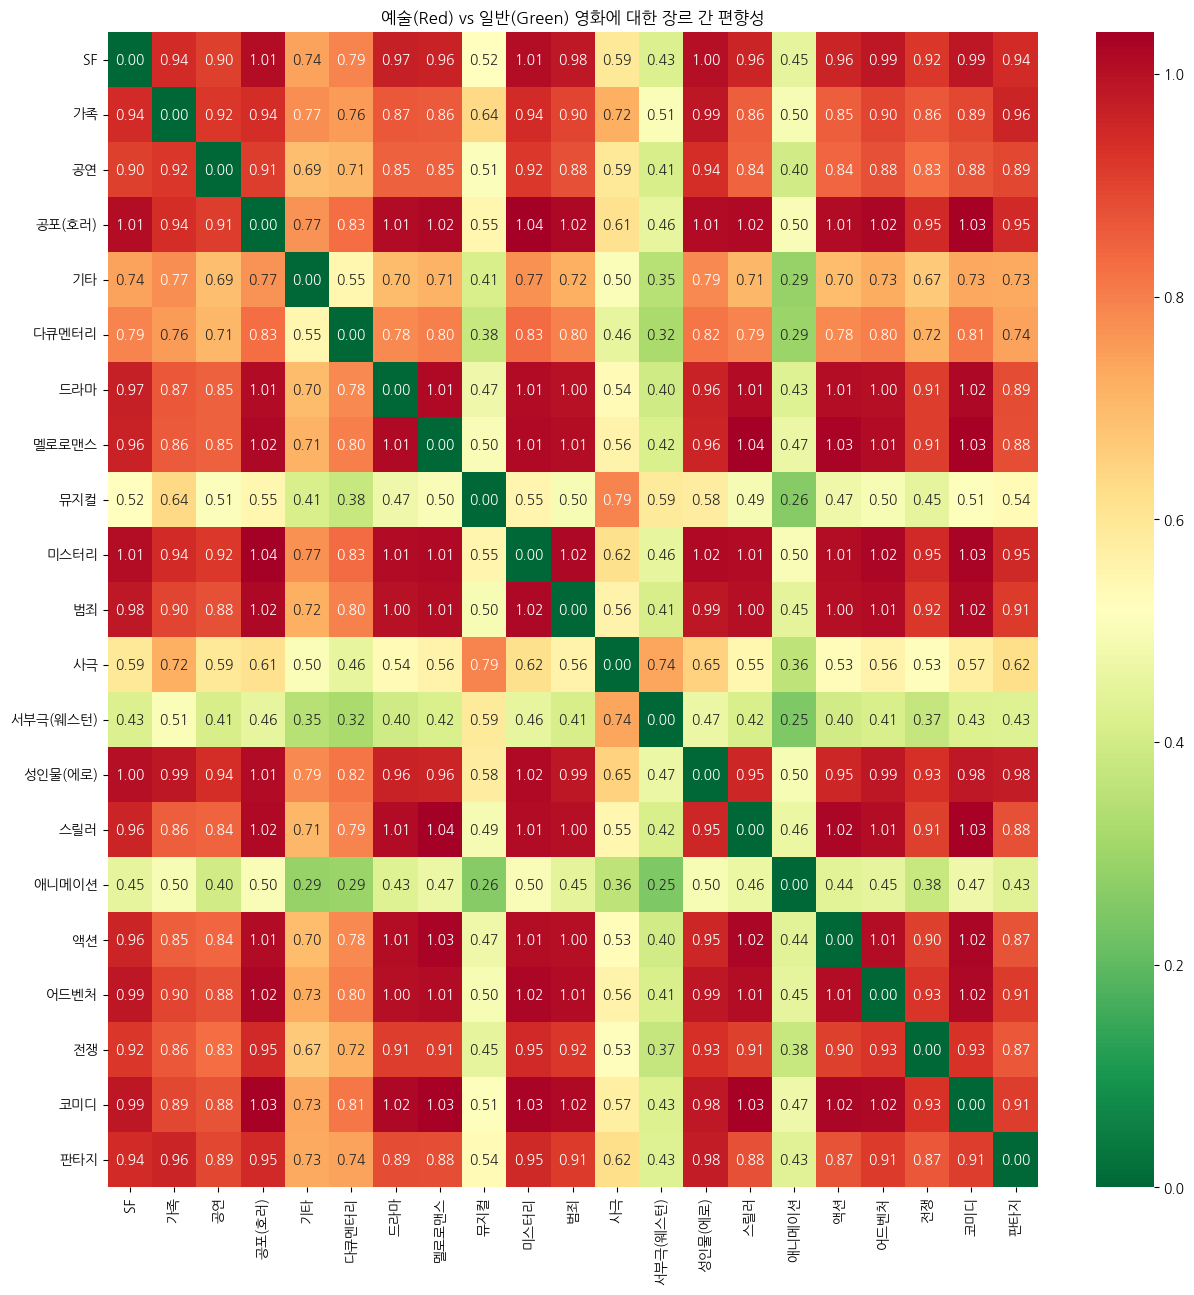

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

if not os.path.exists('NanumGothic-Regular.ttf'):
    !wget "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"


font_path = 'NanumGothic-Regular.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)


plt.rc('axes', unicode_minus=False)


plt.figure(figsize=(15, 15))
sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name,
            annot=True, fmt='.2f', cmap='RdYlGn_r')

plt.title("예술(Red) vs 일반(Green) 영화에 대한 장르 간 편향성")
plt.show()